Saving sample-5s-360p.mp4 to sample-5s-360p (3).mp4
Perspective Transformed Frame:


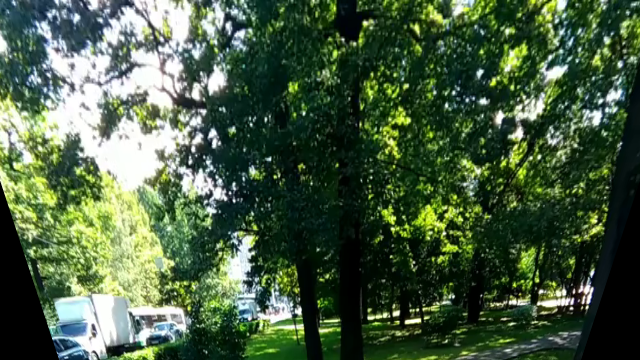

Perspective transformation completed!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload video
uploaded = files.upload()
video_path = list(uploaded.keys())[0]

# Open video
cap = cv2.VideoCapture(video_path)

# Video properties
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# Output video
out = cv2.VideoWriter(
    "perspective_output.mp4",
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (width, height)
)

# Source points (original)
src = np.float32([
    [50, 50],
    [width-50, 50],
    [50, height-50],
    [width-50, height-50]
])

# Destination points (transformed)
dst = np.float32([
    [0, 0],
    [width, 0],
    [100, height],
    [width-100, height]
])

# Perspective transformation matrix
M = cv2.getPerspectiveTransform(src, dst)

first_frame = True

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Apply perspective transformation
    transformed = cv2.warpPerspective(frame, M, (width, height))

    # Display only the first transformed frame
    if first_frame:
        print("Perspective Transformed Frame:")
        cv2_imshow(transformed)
        first_frame = False

    # Save frame
    out.write(transformed)

cap.release()
out.release()

print("Perspective transformation completed!")

# Download the processed video
files.download("perspective_output.mp4")